In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Optional
import operator
from IPython.display import Image, display

In [2]:

# Defining the data or State

class Data(TypedDict):
    name:str
    age:int
    messages: Annotated[list[str], operator.add]

# Graph definition 
graph = StateGraph(Data)


In [3]:
# defining the node 

def Admin(state: Data)-> Optional[Data]:
    print(f"Hii! {state['name']}, Welcome to Snezhnaya!\nWe have a message for you:\n{state['messages']}")
    state['messages'] = ["Hello "+state["name"]]
    return state 

def User(state: Data)-> Optional[Data]:
    print(f"Hii! {state['name']}, you are {state['age']} years old..")
    state['messages'] = ["Hello "+state["name"]]
    return state


def conditionalEdge(state: Data) -> Data:
    return state


# 4. Routing function
def decide(state: Data) -> str:
    if state["name"].lower() == "ruuh":
        return "Yes"

    return "No"


        

In [4]:
# defining the edges
# 5. Add nodes
graph.add_node("conditional_edge", conditionalEdge)
graph.add_node("admin", Admin)
graph.add_node("user", User)


# 6. Conditional edge
graph.add_conditional_edges(
    "conditional_edge",
    decide,
    {
        "Yes": "admin",
        "No": "user"
    }
)


# 7. Normal edges
graph.add_edge(START, "conditional_edge")
graph.add_edge("admin", END)
graph.add_edge("user", END)

app= graph.compile()

app.invoke({
    "name": "Ruuh",
    "age": 22,
    "messages":[]
})

Hii! Ruuh, Welcome to Snezhnaya!
We have a message for you:
[]


{'name': 'Ruuh', 'age': 22, 'messages': ['Hello Ruuh']}

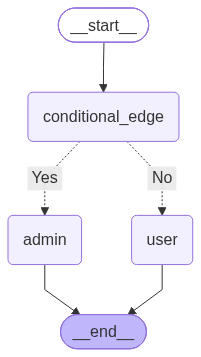

None


In [5]:
print(display(Image(app.get_graph().draw_mermaid_png())))